## **Bài toán 1: Tính xấp xỉ tích tích phân hàm Laplace (phân phối chuẩn) của tích phân sau: $I = \frac{1}{\sqrt{2\pi}} \int_{0}^{2} e^{-\frac{x^2}{2}} \, dx$**


Kết quả mô phỏng với 10000 mẫu
- Số điểm rơi vào miền B: 2382
- Giá trị tích phân xấp xỉ: 0.4764

Kêt quả mô phỏng trung bình với 10000 lần lặp:
- Trung bình số điểm rơi vào miền B: 2386.88
- Giá trị tích phân xấp xỉ trung bình: 0.4774


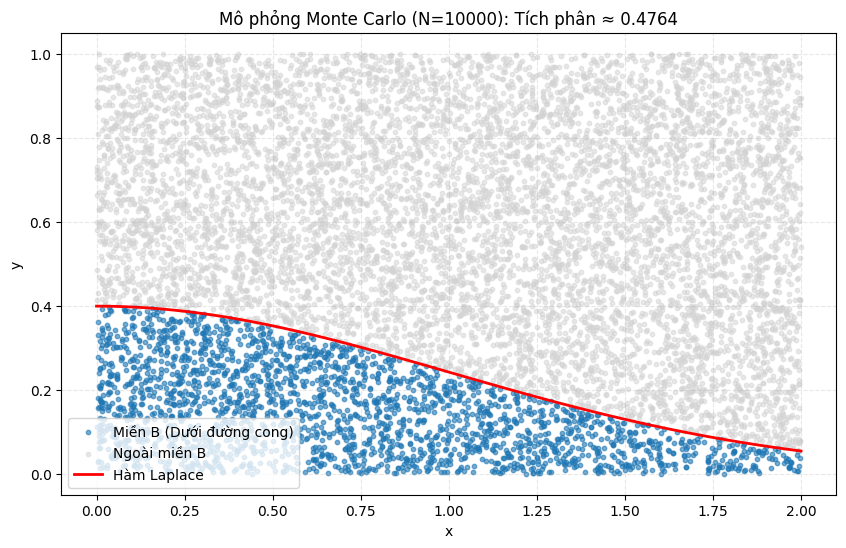

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Định nghĩa các hàm tính toán

def run_single_experiment(n_samples=10000):
    """
    Thực hiện một lần mô phỏng Monte Carlo.
    Trả về số điểm trong miền B và dữ liệu để vẽ hình.
    """
    # Sinh mẫu ngẫu nhiên
    x = np.random.uniform(0, 2, n_samples)
    y = np.random.uniform(0, 1, n_samples)

    # Tính toán đường cong Laplace lý thuyết tại các điểm x
    # f(x) = (1 / sqrt(2*pi)) * exp(-x^2 / 2)
    curve_y = (1 / np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2)

    # Kiểm tra điều kiện: điểm nằm dưới đường cong (thuộc miền B)
    condition = y < curve_y

    # Đếm số lượng điểm thỏa mãn
    n_B = np.sum(condition)

    # Trả về: số điểm thỏa mãn, tọa độ x, tọa độ y, và mảng điều kiện (để vẽ màu)
    return n_B, x, y, condition

def run_averaged_experiment(n_repeats, m_samples):
    """
    Thực hiện lặp lại thí nghiệm n_repeats lần để lấy trung bình (Luật số lớn).
    """
    results = np.zeros(n_repeats)

    for i in range(n_repeats):
        # Gọi lại logic của một lần chạy (chỉ lấy số lượng n_B)
        n_B, _, _, _ = run_single_experiment(m_samples)
        results[i] = n_B

    # Trả về giá trị trung bình của số điểm rơi vào miền B
    return np.mean(results)

if __name__ == "__main__":
    # Cấu hình chung
    N_SAMPLES = 10000  # Số điểm cho một lần chạy (m)
    N_REPEATS = 10000   # Số lần lặp lại (n)
    AREA_RECT = 2      # Diện tích hình chữ nhật bao quanh (Rộng 2 x Cao 1)


    # --- Chạy mô phỏng ---
    print(f"\nKết quả mô phỏng với {N_REPEATS} mẫu")
    n_B_single, x, y, condition = run_single_experiment(N_SAMPLES)
    integral_single = AREA_RECT * (n_B_single / N_SAMPLES)

    print(f"- Số điểm rơi vào miền B: {n_B_single}")
    print(f"- Giá trị tích phân xấp xỉ: {integral_single:.4f}")

    # --- Chạy mô phỏng lặp lại lấy trung bình ---
    print(f"\nKêt quả mô phỏng trung bình với {N_REPEATS} lần lặp:")
    avg_count = run_averaged_experiment(N_REPEATS, N_SAMPLES)
    integral_avg = AREA_RECT * (avg_count / N_SAMPLES)

    print(f"- Trung bình số điểm rơi vào miền B: {avg_count:.2f}")
    print(f"- Giá trị tích phân xấp xỉ trung bình: {integral_avg:.4f}")

    # Vẽ biểu đồ minh hoạ
    plt.figure(figsize=(10, 6))

    # Vẽ các điểm thuộc miền B (Màu xanh)
    plt.scatter(x[condition], y[condition], color='#1f77b4', s=10, alpha=0.6, label='Miền B (Dưới đường cong)')

    # Vẽ các điểm ngoài miền B (Màu xám)
    plt.scatter(x[~condition], y[~condition], color='lightgray', s=10, alpha=0.5, label='Ngoài miền B')

    # Vẽ đường cong lý thuyết
    x_line = np.linspace(0, 2, 100)
    y_line = (1 / np.sqrt(2 * np.pi)) * np.exp(-x_line**2 / 2)
    plt.plot(x_line, y_line, color='red', linewidth=2, label='Hàm Laplace')

    plt.title(f'Mô phỏng Monte Carlo (N={N_SAMPLES}): Tích phân ≈ {integral_single:.4f}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.show()

## **Bài toán 2: Tính xấp xỉ giá trị số $\pi$**

------------------------------------------------------------
MÔ PHỎNG MONTE CARLO (Mẫu: 10000, Lặp: 10000)
------------------------------------------------------------

Kết quả mô phỏng với 10000 mẫu:
- Số điểm trong hình tròn: 7874
- Giá trị Pi xấp xỉ: 3.1496

Kết quả mô phỏng trung bình với 10000 lần lặp
- Số điểm trung bình trong hình tròn: 7854.17
- Số Pi xấp xỉ trung bình: 3.14167


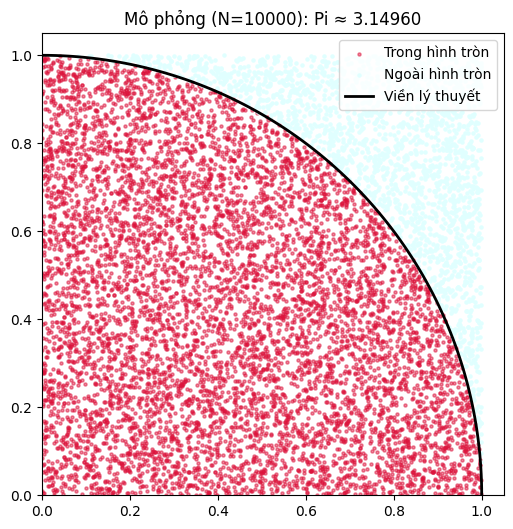

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Định nghĩa các hàm tính toán

def run_single_experiment(n_samples=10000):
    """
    Thực hiện một lần mô phỏng Monte Carlo để tính Pi.
    """
    # Sinh ngẫu nhiên x, y trong [0, 1]
    x = np.random.uniform(0, 1, n_samples)
    y = np.random.uniform(0, 1, n_samples)

    # Tính z = x^2 + y^2
    # Kiểm tra điều kiện điểm nằm trong hình tròn đơn vị (z < 1)
    condition = x**2 + y**2 < 1

    # Đếm số điểm thỏa mãn
    n_inside = np.sum(condition)

    # Trả về: số điểm bên trong, dữ liệu x, y, và mảng điều kiện (để vẽ hình)
    return n_inside, x, y, condition

def run_averaged_experiment(n_repeats=1000, m_samples=10000):
    """
    Thực hiện lặp lại thí nghiệm n_repeats lần để lấy trung bình.
    """
    pi_values = np.zeros(n_repeats)    # Lưu Pi của mỗi lần
    count_values = np.zeros(n_repeats) # Lưu số điểm trong hình tròn của mỗi lần

    for i in range(n_repeats):
        # Sinh mẫu ngẫu nhiên
        x = np.random.uniform(0, 1, m_samples)
        y = np.random.uniform(0, 1, m_samples)

        # Đếm số điểm trong hình tròn
        count = np.sum(x**2 + y**2 < 1)

        # Lưu lại kết quả
        count_values[i] = count
        pi_values[i] = 4 * (count / m_samples)

    # Trả về cả 2 giá trị trung bình: (Pi trung bình, Số điểm trung bình)
    return np.mean(pi_values), np.mean(count_values)

if __name__ == "__main__":
    # --- CẤU HÌNH ---
    N_SAMPLES = 10000
    N_REPEATS = 10000

    print("-" * 60)
    print(f"MÔ PHỎNG MONTE CARLO (Mẫu: {N_SAMPLES}, Lặp: {N_REPEATS})")
    print("-" * 60)

    # --- Thực hiện mô phỏng ---
    n_inside, x_data, y_data, condition_data = run_single_experiment(N_SAMPLES)

    pi_single = 4 * (n_inside / N_SAMPLES)

    print(f"\nKết quả mô phỏng với {N_SAMPLES} mẫu:")
    print(f"- Số điểm trong hình tròn: {n_inside}")
    print(f"- Giá trị Pi xấp xỉ: {pi_single}")

    # Thực hiện tính giá trị trung bình ---
    print(f"\nKết quả mô phỏng trung bình với {N_REPEATS} lần lặp")
    pi_final, avg_count = run_averaged_experiment(N_REPEATS, N_SAMPLES)

    print(f"- Số điểm trung bình trong hình tròn: {avg_count:.2f}")
    print(f"- Số Pi xấp xỉ trung bình: {pi_final:.5f}")



    plt.figure(figsize=(6, 6))

    # Vẽ các điểm thuộc hình tròn (Dùng x_data, y_data cũ)
    plt.scatter(x_data[condition_data], y_data[condition_data],
                color='crimson', s=5, alpha=0.5, label='Trong hình tròn')

    # Vẽ các điểm ngoài hình tròn
    plt.scatter(x_data[~condition_data], y_data[~condition_data],
                color='lightcyan', s=5, label='Ngoài hình tròn')

    # Vẽ viền hình tròn lý thuyết
    theta = np.linspace(0, np.pi/2, 100)
    plt.plot(np.cos(theta), np.sin(theta), color='black', linewidth=2, label='Viền lý thuyết')

    # Tiêu đề dùng chính biến pi_single đã in ra console
    plt.title(f'Mô phỏng (N={N_SAMPLES}): Pi ≈ {pi_single:.5f}')

    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend(loc='upper right')
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)

    plt.show()

## **Bài toán 3: Chọn ngẫu nhiên 3 đoạn thẳng, mỗi đoạn thẳng có độ dài không vượt quá số $a>0$ cho trước. Tìm xác suất sao cho các đoạn thẳng đó là các cạnh của một tam giác, của một tam giác tù.**

Kết quả thực hiện với số mẫu tương ứng
       Mẫu |   Số lượng |   Xác suất
----------------------------------------
       100 |         46 |    0.46000
      1000 |        494 |    0.49400
     10000 |       4979 |    0.49790
    100000 |      50098 |    0.50098

Kết quả trung bình sau 10000 lần lặp
       Mẫu | TB Số lượng | TB Xác suất
----------------------------------------
       100 |      49.96 |    0.49958
      1000 |     499.88 |    0.49988
     10000 |    5000.28 |    0.50003
    100000 |   49999.17 |    0.49999


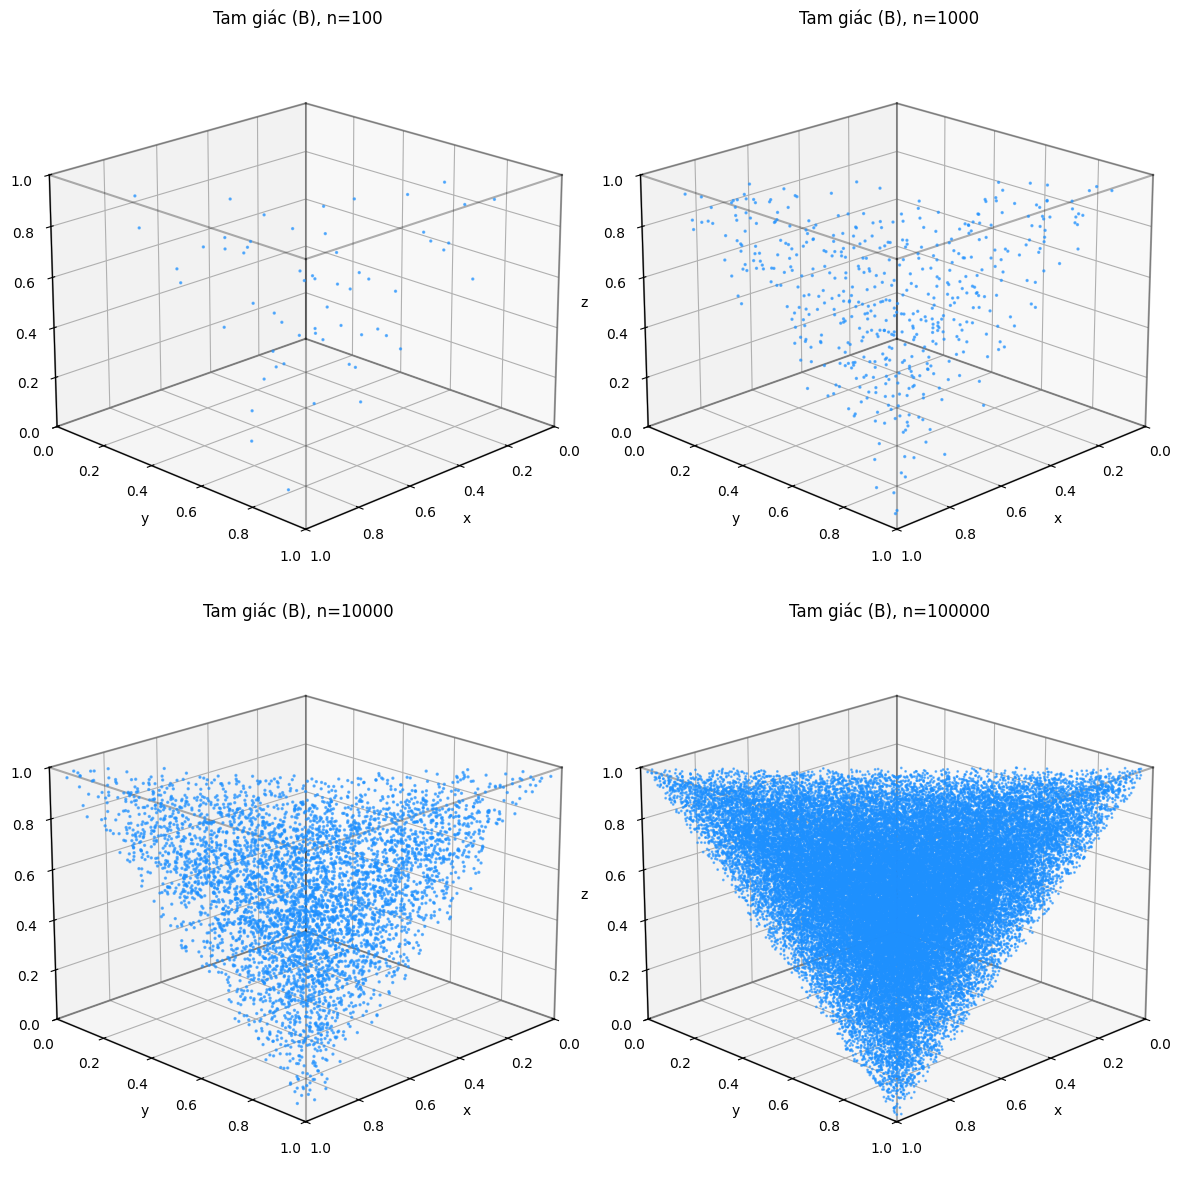

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import product, combinations

# Các hàm tính toán

def run_single_experiment(n_samples):
    """
    Thực hiện 1 lần mô phỏng duy nhất.
    Trả về cả dữ liệu thô để phục vụ vẽ đồ thị.
    """
    # Sinh ngẫu nhiên n bộ 3 cạnh (x, y, z)
    data = np.random.uniform(0, 1, (n_samples, 3))
    x, y, z = data[:, 0], data[:, 1], data[:, 2]

    # Điều kiện bất đẳng thức tam giác
    condition = (x + y > z) & (x + z > y) & (y + z > x)

    count = np.sum(condition)
    prob = count / n_samples

    # Trả về: count, prob, dữ liệu gốc, mask điều kiện
    return count, prob, data, condition

def run_averaged_experiment(n_repeats, n_samples):
    """
    Thực hiện lặp lại thí nghiệm n_repeats lần để lấy trung bình (Monte Carlo).
    """
    counts = np.zeros(n_repeats)

    for i in range(n_repeats):
        # Chỉ lấy biến count
        c, _, _, _ = run_single_experiment(n_samples)
        counts[i] = c

    # Tính các giá trị trung bình
    avg_count = np.mean(counts)
    avg_prob = avg_count / n_samples

    return avg_count, avg_prob

# Hàm vẽ hình

def visualize_triangle_multi_n(sample_sizes):
    """
    Vẽ đồ thị 3D so sánh mật độ điểm với các kích thước mẫu khác nhau.
    Tự động chia lưới 2x2 nếu có 4 mẫu.
    """
    fig = plt.figure(figsize=(12, 12))

    # Xác định bố cục lưới (2x2 nếu là 4 mẫu, ngược lại 1 hàng ngang)
    nrows = 2 if len(sample_sizes) == 4 else 1
    ncols = 2 if len(sample_sizes) == 4 else len(sample_sizes)

    for i, n in enumerate(sample_sizes):
        # Lấy dữ liệu
        _, _, data, condition = run_single_experiment(n)

        # Tạo subplot
        ax = fig.add_subplot(nrows, ncols, i + 1, projection="3d")

        # Điều chỉnh kích thước điểm (s) nhỏ lại khi n quá lớn để đỡ bị đặc
        point_size = 1 if n >= 100000 else 2

        # Vẽ các điểm thỏa mãn (Màu xanh)
        ax.scatter(
            data[condition, 0],
            data[condition, 1],
            data[condition, 2],
            c="dodgerblue",
            s=point_size,
            alpha=0.6
        )

        # Vẽ khung hình lập phương
        r = [0, 1]
        for s, e in combinations(np.array(list(product(r, r, r))), 2):
            if np.sum(np.abs(s - e)) == 1:
                ax.plot3D(*zip(s, e), color="black", alpha=0.3)

        ax.set_title(f"Tam giác (B), n={n}")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_zlim(0, 1)
        ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
        ax.view_init(elev=20, azim=45)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":

    sample_sizes = [100, 1000, 10000, 100000]
    FIXED_REPEATS = 10000

    # KẾT QUẢ CHẠY ĐƠN LẺ
    print(f"Kết quả thực hiện với số mẫu tương ứng")
    print(f"{'Mẫu':>10} | {'Số lượng':>10} | {'Xác suất':>10}")
    print("-" * 40)

    for n in sample_sizes:
        count, prob, _, _ = run_single_experiment(n)
        print(f"{n:>10} | {count:>10} | {prob:>10.5f}")

    #KẾT QUẢ CHẠY LẶP LẠI
    print(f"\nKết quả trung bình sau {FIXED_REPEATS} lần lặp")
    print(f"{'Mẫu':>10} | {'TB Số lượng':>10} | {'TB Xác suất':>10}")
    print("-" * 40)

    for n in sample_sizes:
        avg_count, avg_prob = run_averaged_experiment(FIXED_REPEATS, n)
        print(f"{n:>10} | {avg_count:>10.2f} | {avg_prob:>10.5f}")


    visualize_triangle_multi_n(sample_sizes)

Kết quả mô phỏng:
       Mẫu |   Số lượng |   Xác suất
----------------------------------------
       100 |         21 |    0.21000
      1000 |        295 |    0.29500
     10000 |       2812 |    0.28120
    100000 |      28199 |    0.28199

Kết quả mô phỏng trung bình sau 10000 
       Mẫu | TB Số lượng | TB Xác suất
----------------------------------------
       100 |      28.56 |    0.28558
      1000 |     285.27 |    0.28528
     10000 |    2853.76 |    0.28538
    100000 |   28538.55 |    0.28539


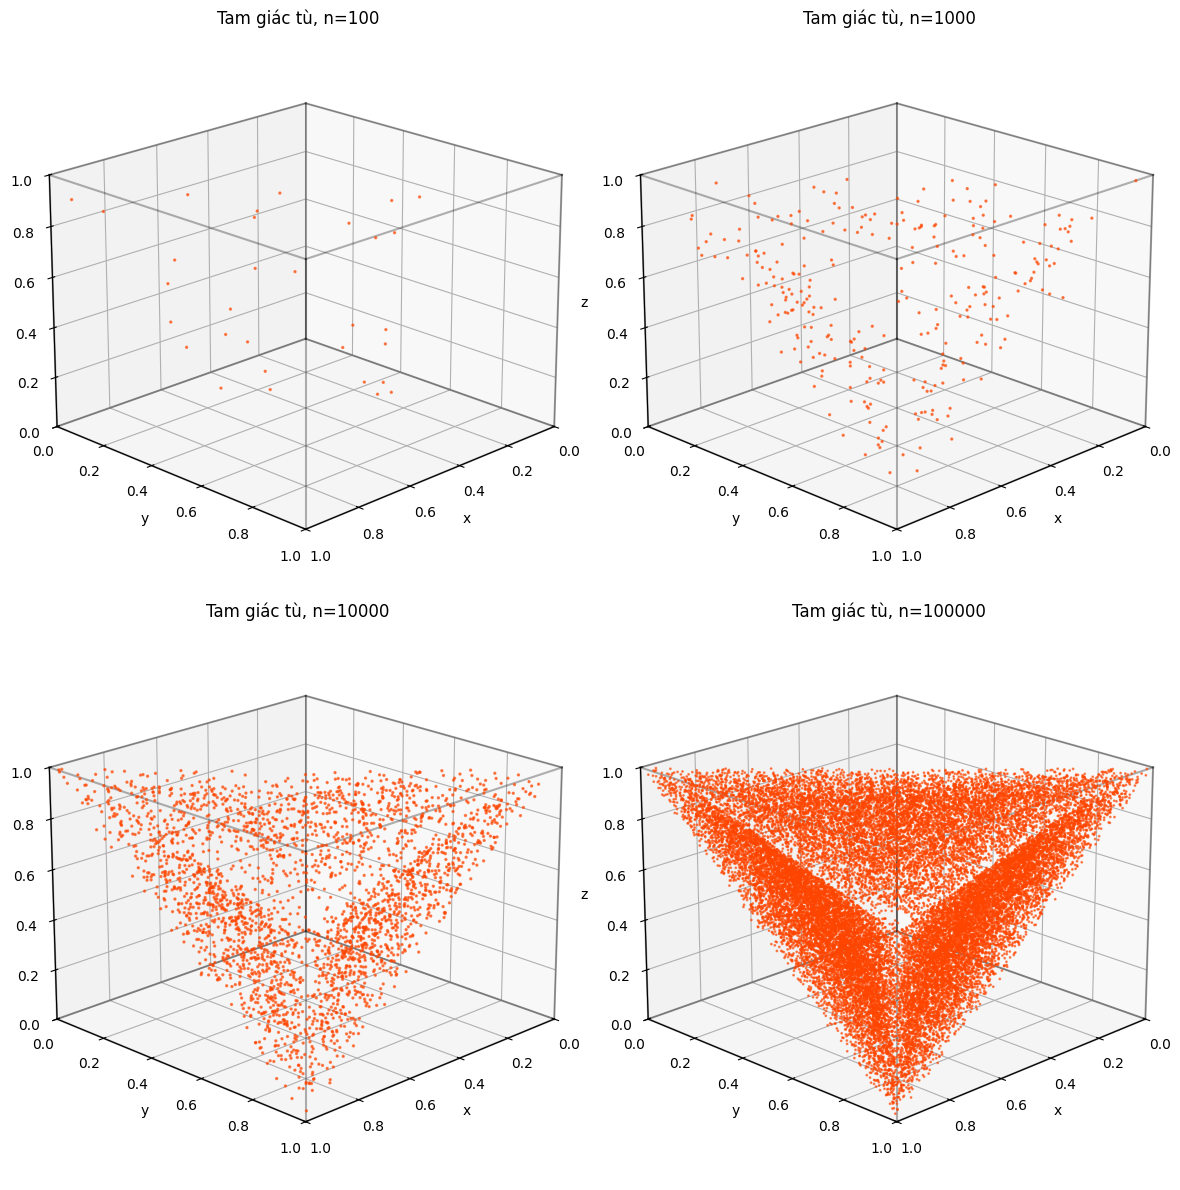

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import product, combinations

# Các hàm cài đặt
def run_single_experiment_obtuse(n_samples):
    """
    Thực hiện 1 lần mô phỏng xác suất Tam giác TÙ.
    Trả về dữ liệu thô để vẽ hình.
    """
    # 1. Sinh ngẫu nhiên n bộ 3 cạnh (x, y, z)
    data = np.random.uniform(0, 1, (n_samples, 3))
    x, y, z = data[:, 0], data[:, 1], data[:, 2]

    # 2. Điều kiện 1: Phải là Tam giác trước
    is_triangle = (x + y > z) & (x + z > y) & (y + z > x)

    # 3. Điều kiện 2: Phải là Tam giác TÙ (a^2 + b^2 < c^2)
    is_obtuse_cond = (x**2 + y**2 < z**2) | \
                     (x**2 + z**2 < y**2) | \
                     (y**2 + z**2 < x**2)

    # Kết hợp cả 2 điều kiện (AND)
    condition = is_triangle & is_obtuse_cond

    count = np.sum(condition)
    prob = count / n_samples

    # Trả về: count, prob, dữ liệu gốc, mask điều kiện
    return count, prob, data, condition

def run_averaged_experiment_obtuse(n_repeats, n_samples):
    """
    Thực hiện lặp lại thí nghiệm n_repeats lần để lấy trung bình.
    """
    counts = np.zeros(n_repeats)

    for i in range(n_repeats):
        # Chỉ lấy biến count
        c, _, _, _ = run_single_experiment_obtuse(n_samples)
        counts[i] = c

    # Tính các giá trị trung bình
    avg_count = np.mean(counts)
    avg_prob = avg_count / n_samples

    return avg_count, avg_prob

# Hàm vẽ đồ thị

def visualize_obtuse_multi_n(sample_sizes):
    """
    Vẽ đồ thị 3D so sánh mật độ Tam giác TÙ với các kích thước mẫu khác nhau.
    """

    fig = plt.figure(figsize=(12, 12))

    # Xác định bố cục lưới (2x2)
    nrows = 2
    ncols = 2

    for i, n in enumerate(sample_sizes):
        # Lấy dữ liệu
        _, _, data, condition = run_single_experiment_obtuse(n)

        # Tạo subplot
        ax = fig.add_subplot(nrows, ncols, i + 1, projection="3d")

        # Điều chỉnh kích thước điểm
        point_size = 1 if n >= 100000 else 2

        # Vẽ các điểm thỏa mãn Tam giác Tù (Màu đỏ/cam để khác biệt)
        ax.scatter(
            data[condition, 0],
            data[condition, 1],
            data[condition, 2],
            c="orangered",  # Dùng màu cam đỏ cho tam giác tù
            s=point_size,
            alpha=0.6
        )

        # Vẽ khung hình lập phương
        r = [0, 1]
        for s, e in combinations(np.array(list(product(r, r, r))), 2):
            if np.sum(np.abs(s - e)) == 1:
                ax.plot3D(*zip(s, e), color="black", alpha=0.3)

        ax.set_title(f"Tam giác tù, n={n}")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_zlim(0, 1)
        ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
        ax.view_init(elev=20, azim=45)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":

    sample_sizes = [100, 1000, 10000, 100000]
    FIXED_REPEATS = 10000


    # Kết quả mô phỏng
    print(f"Kết quả mô phỏng:")
    print(f"{'Mẫu':>10} | {'Số lượng':>10} | {'Xác suất':>10}")
    print("-" * 40)

    for n in sample_sizes:
        count, prob, _, _ = run_single_experiment_obtuse(n)
        print(f"{n:>10} | {count:>10} | {prob:>10.5f}")

    # Kết quả mô phỏng trung bình
    print(f"\nKết quả mô phỏng trung bình sau {FIXED_REPEATS} ")
    print(f"{'Mẫu':>10} | {'TB Số lượng':>10} | {'TB Xác suất':>10}")
    print("-" * 40)

    for n in sample_sizes:
        avg_count, avg_prob = run_averaged_experiment_obtuse(FIXED_REPEATS, n)
        print(f"{n:>10} | {avg_count:>10.2f} | {avg_prob:>10.5f}")

    visualize_obtuse_multi_n(sample_sizes)